# 🎬 MovieMate — Conversational AI for Intelligent Movie Search & Recommendations

This notebook fulfills all deliverables for the MovieMate project:
1. Dataset Exploration
2. Exploratory Data Analysis
3. Data Preprocessing
4. Embedding & Retrieval (FAISS)
5. Conversational Movie Chatbot (RAG + LLM)
6. Interactive Interface (Gradio)
7. Evaluation & Reflection

**Dataset:** IMDb Movies Dataset from Kaggle (`https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows`)

## ⚙️ Step 0 — Install Dependencies

In [5]:
!pip install -q kaggle pandas numpy matplotlib seaborn sentence-transformers faiss-cpu openai gradio
!pip install streamlit


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📥 Step 1 — Download Dataset from Kaggle

**Prerequisites:** Place your `kaggle.json` API token in `~/.kaggle/kaggle.json`  
Get it from: https://www.kaggle.com/settings → API → Create New Token

In [6]:
import os

os.environ["KAGGLE_USERNAME"] = "..."
os.environ["KAGGLE_KEY"]      = "..."

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows --unzip -p ./data
print("✅ Dataset downloaded successfully.")

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0

✅ Dataset downloaded successfully.



  0%|          | 0.00/175k [00:00<?, ?B/s]
100%|##########| 175k/175k [00:00<00:00, 179MB/s]


## 📊 Step 2 — Dataset Exploration

In [7]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("./data/imdb_top_1000.csv")

print("=" * 60)
print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print("=" * 60)
df.head(5)

Dataset shape : (1000, 16)
Columns       : ['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [8]:
# ── Summary statistics ────────────────────────────────────────────────────────
print("\n📌 Data Types:\n", df.dtypes)
print("\n📌 Null Counts:\n", df.isnull().sum())
print("\n📌 Numeric Summary:\n")
df.describe()


📌 Data Types:
 Poster_Link       object
Series_Title      object
Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross             object
dtype: object

📌 Null Counts:
 Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

📌 Numeric Summary:



,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


## 📈 Step 3 — Exploratory Data Analysis (EDA)

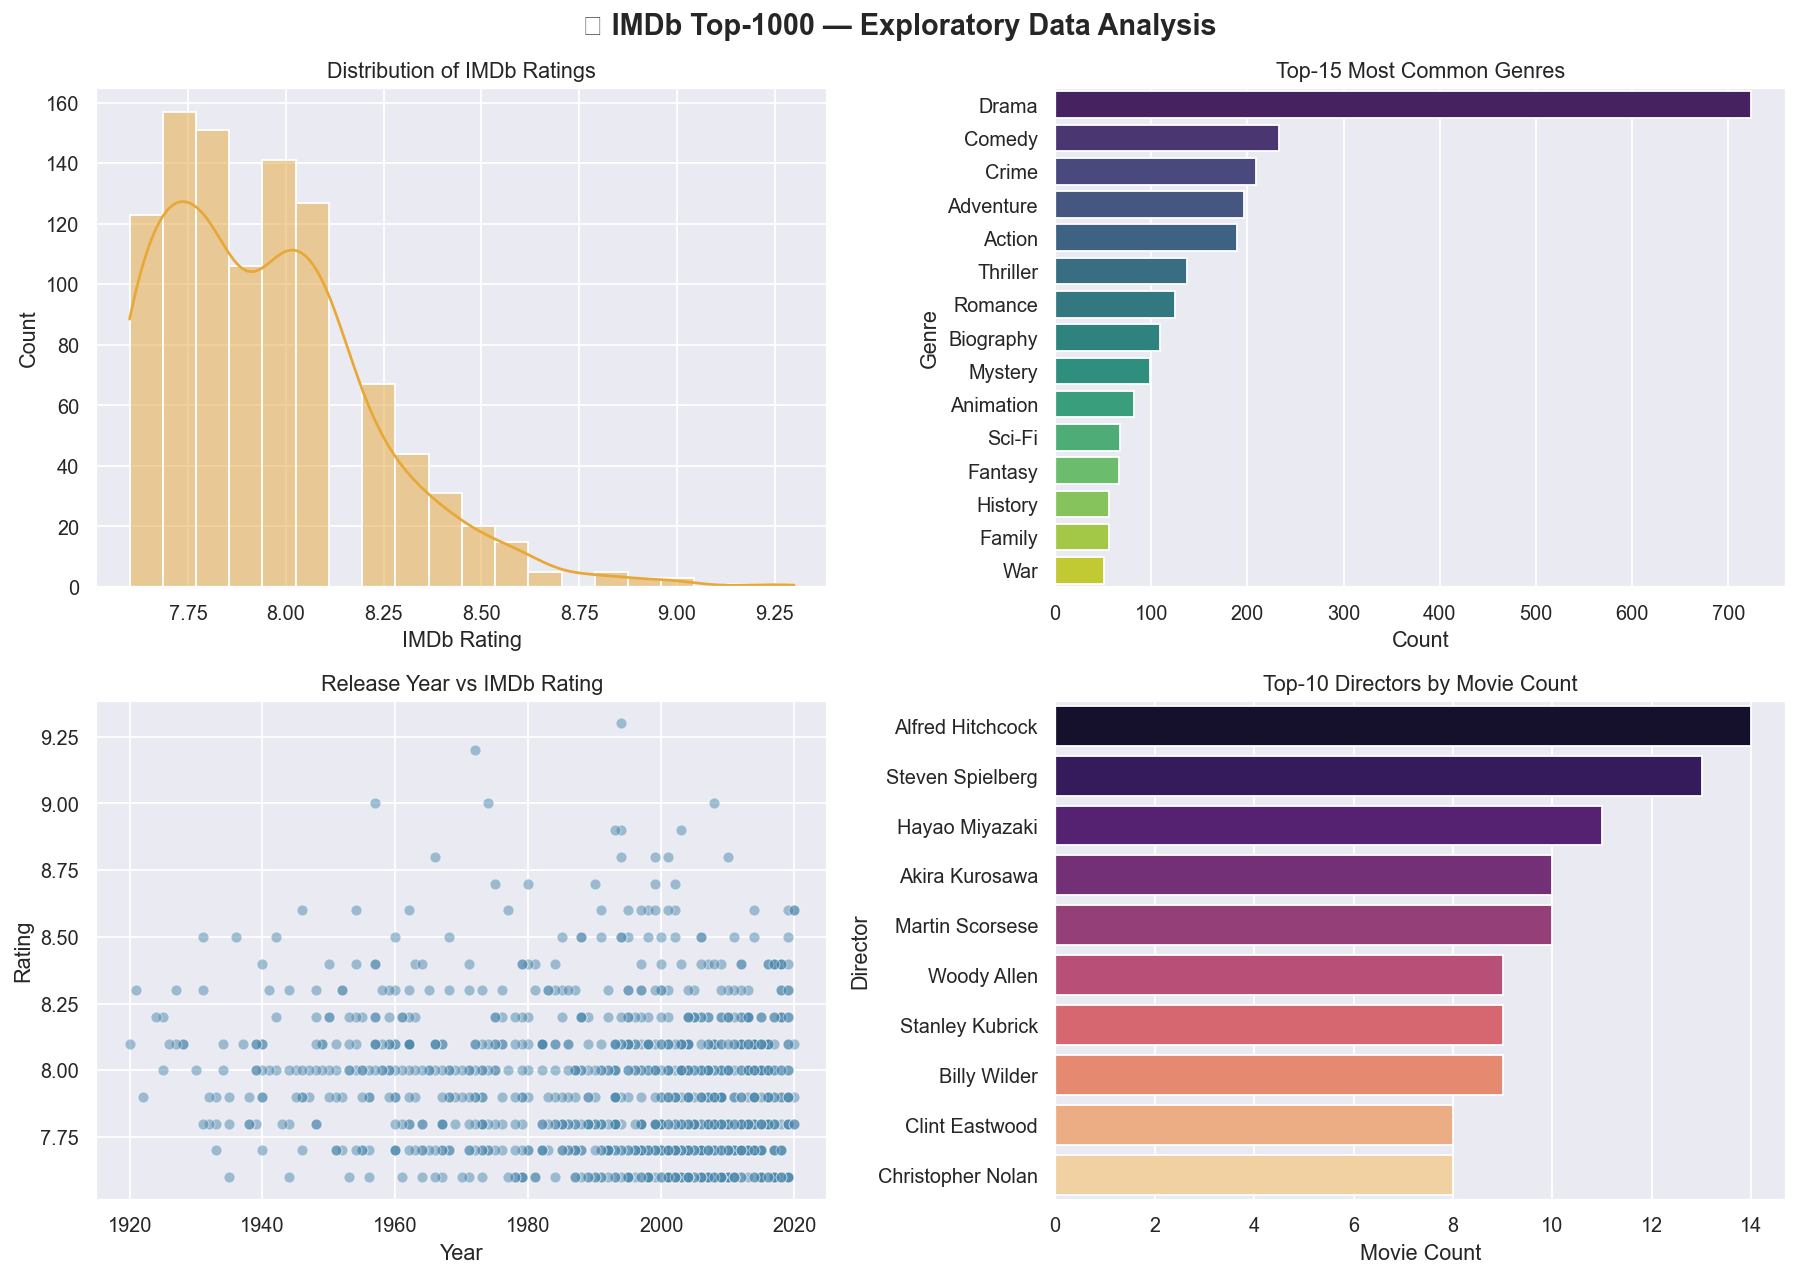

✅ EDA charts saved.


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("🎬 IMDb Top-1000 — Exploratory Data Analysis", fontsize=16, fontweight="bold")

axes[0, 0].set_title("Distribution of IMDb Ratings")
sns.histplot(df["IMDB_Rating"].dropna(), bins=20, kde=True, color="#E8A838", ax=axes[0, 0])
axes[0, 0].set_xlabel("IMDb Rating")
axes[0, 0].set_ylabel("Count")

from collections import Counter
genre_counts = Counter()
for entry in df["Genre"].dropna():
    for g in entry.split(","):
        genre_counts[g.strip()] += 1
genre_df = pd.DataFrame(genre_counts.most_common(15), columns=["Genre", "Count"])
axes[0, 1].set_title("Top-15 Most Common Genres")
sns.barplot(data=genre_df, x="Count", y="Genre", palette="viridis", ax=axes[0, 1])
axes[0, 1].set_xlabel("Count")

axes[1, 0].set_title("Release Year vs IMDb Rating")
year_rating = df[["Released_Year", "IMDB_Rating"]].dropna()
year_rating["Released_Year"] = pd.to_numeric(year_rating["Released_Year"], errors="coerce")
year_rating = year_rating.dropna()
sns.scatterplot(data=year_rating, x="Released_Year", y="IMDB_Rating",
                alpha=0.5, color="#4E89AE", ax=axes[1, 0])
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Rating")

top_directors = df["Director"].value_counts().head(10)
axes[1, 1].set_title("Top-10 Directors by Movie Count")
sns.barplot(x=top_directors.values, y=top_directors.index, palette="magma", ax=axes[1, 1])
axes[1, 1].set_xlabel("Movie Count")

plt.tight_layout()
plt.savefig("./data/eda_charts.png", bbox_inches="tight")
plt.show()
print("✅ EDA charts saved.")

## 🧹 Step 4 — Data Preprocessing

In [10]:
import re

df.rename(columns={
    "Series_Title": "Title",
    "Released_Year": "Year",
    "Runtime": "Duration",
    "IMDB_Rating": "Rating",
    "Overview": "Summary",
    "Star1": "Lead_Actor"
}, inplace=True)

df["Year"]   = pd.to_numeric(df["Year"],   errors="coerce")
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df["Duration_Min"] = df["Duration"].str.extract(r"(\d+)").astype(float)

before = len(df)
df.dropna(subset=["Title", "Rating", "Genre", "Director"], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Rows before cleaning: {before} → after: {len(df)}")

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\s+", " ", text).strip()
    return text

for col in ["Title", "Genre", "Director", "Lead_Actor", "Summary"]:
    if col in df.columns:
        df[col] = df[col].apply(clean_text)

def build_doc(row):
    parts = [
        f"Title: {row.get('Title', '')}",
        f"Year: {int(row['Year']) if not pd.isna(row.get('Year')) else 'N/A'}",
        f"Genre: {row.get('Genre', '')}",
        f"Director: {row.get('Director', '')}",
        f"Cast: {row.get('Lead_Actor', '')} {row.get('Star2', '')} {row.get('Star3', '')}".strip(),
        f"Rating: {row.get('Rating', 'N/A')}",
        f"Duration: {int(row['Duration_Min']) if not pd.isna(row.get('Duration_Min')) else 'N/A'} min",
        f"Summary: {row.get('Summary', '')}",
    ]
    return " | ".join(parts)

df["document"] = df.apply(build_doc, axis=1)

print("\n✅ Preprocessing complete. Sample document:")
print(df["document"].iloc[0])

Rows before cleaning: 1000 → after: 1000

✅ Preprocessing complete. Sample document:
Title: The Shawshank Redemption | Year: 1994 | Genre: Drama | Director: Frank Darabont | Cast: Tim Robbins Morgan Freeman Bob Gunton | Rating: 9.3 | Duration: 142 min | Summary: Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.


## 🔢 Step 5 — Embedding Generation & FAISS Vector Index

In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import pickle

print("⏳ Loading embedding model (all-MiniLM-L6-v2)…")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("⏳ Generating document embeddings…")
documents  = df["document"].tolist()
embeddings = embedder.encode(documents, show_progress_bar=True, convert_to_numpy=True)

faiss.normalize_L2(embeddings)
dim   = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings)

os.makedirs("./data", exist_ok=True)
faiss.write_index(index, "./data/movies.index")
df.to_pickle("./data/movies_df.pkl")

print(f"✅ FAISS index built with {index.ntotal} vectors (dim={dim}).")

## 🔍 Step 6 — Retrieval Function

In [ ]:
def retrieve_movies(query: str, top_k: int = 5) -> list[dict]:
    """Embed query → FAISS nearest-neighbour search → return top_k movie dicts."""
    q_emb = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue
        row = df.iloc[idx]
        results.append({
            "title"     : row["Title"],
            "year"      : int(row["Year"]) if not pd.isna(row["Year"]) else "N/A",
            "genre"     : row["Genre"],
            "director"  : row["Director"],
            "rating"    : row["Rating"],
            "duration"  : f"{int(row['Duration_Min'])} min" if not pd.isna(row["Duration_Min"]) else "N/A",
            "cast"      : row.get("Lead_Actor", ""),
            "summary"   : row.get("Summary", ""),
            "score"     : round(float(score), 4),
        })
    return results

test_results = retrieve_movies("sci-fi movies with space exploration")
for r in test_results:
    print(f"  [{r['score']:.3f}] {r['title']} ({r['year']}) — {r['genre']}")

In [ ]:
from openai import OpenAI

client = OpenAI(
    api_key="[YOUR_API_KEY]",
    base_url="https://api.groq.com/openai/v1",
)
MODEL = "llama-3.3-70b-versatile"

SYSTEM_PROMPT = """
You are MovieMate, an expert movie assistant. You help users discover and explore films.
When presented with retrieved movie data, craft a warm, knowledgeable, conversational response.
Always mention the movie title, year, rating, and a brief reason why it fits the user's query.
If the user asks a follow-up, factor in the conversation history.
Keep responses concise — 3 to 6 sentences per recommendation.
""".strip()


def build_context(movies: list[dict]) -> str:
    """Format retrieved movies as a numbered context block for the LLM."""
    lines = []
    for i, m in enumerate(movies, 1):
        lines.append(
            f"{i}. {m['title']} ({m['year']}) | Genre: {m['genre']} | "
            f"Director: {m['director']} | Rating: {m['rating']} | "
            f"Duration: {m['duration']} | Cast: {m['cast']}\n"
            f"   Summary: {m['summary'][:180]}…"
        )
    return "\n".join(lines)


def chat_with_moviemate(user_message: str, history: list[dict]) -> tuple[str, list[dict]]:
    """
    Multi-turn RAG chatbot.
    history: list of {"role": "user"|"assistant", "content": str}
    Returns (assistant_reply, updated_history)
    """
    movies  = retrieve_movies(user_message, top_k=5)
    context = build_context(movies)

    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    messages += history
    messages.append({
        "role": "user",
        "content": (
            f"User query: {user_message}\n\n"
            f"Retrieved movies from the database:\n{context}\n\n"
            "Based on this data, give a helpful, conversational recommendation."
        )
    })

    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0.7,
        max_tokens=600,
    )
    reply = response.choices[0].message.content.strip()

    history.append({"role": "user",      "content": user_message})
    history.append({"role": "assistant", "content": reply})

    return reply, history

reply, hist = chat_with_moviemate("Suggest some great sci-fi movies after 2010", [])
print("🤖 MovieMate:", reply)

In [ ]:
import os

api_key = os.getenv("GROQ_API_KEY")

if api_key:
    client = OpenAI(
        api_key=api_key,
        base_url="https://api.groq.com/openai/v1"
    )
else:
    client = None

In [ ]:
if client:
    # LLM response
    response = client.chat.completions.create(...)
    print(response.choices[0].message.content)
else:
    print("LLM disabled — showing retrieved results:\n")
    for _, row in results.iterrows():
        print(f"{row['Title']} ({row['Year']}) ⭐ {row['Rating']}")

## 💬 Step 8 — Multi-Turn Conversation Demo (no UI)

In [ ]:
conversation_history = []

queries = [
    "Suggest action movies.",
    "Only those released after 2015.",
    "Which of those has the highest IMDb rating?",
]

for q in queries:
    print(f"\n👤 User: {q}")
    response, conversation_history = chat_with_moviemate(q, conversation_history)
    print(f"🤖 MovieMate: {response}")
    print("-" * 70)

## 📏 Step 10 — Evaluation & Reflection

In [ ]:
test_cases = [
    {"query": "action movies",           "expected_genre": "Action"},
    {"query": "horror films",            "expected_genre": "Horror"},
    {"query": "romantic comedies",       "expected_genre": "Romance"},
    {"query": "animated family films",   "expected_genre": "Animation"},
    {"query": "crime thriller movies",   "expected_genre": "Crime"},
]

results_log = []
for tc in test_cases:
    retrieved = retrieve_movies(tc["query"], top_k=5)
    hits = sum(1 for r in retrieved if tc["expected_genre"].lower() in r["genre"].lower())
    precision = hits / len(retrieved)
    results_log.append({
        "Query": tc["query"],
        "Expected Genre": tc["expected_genre"],
        "Hits@5": hits,
        "Precision@5": round(precision, 2)
    })

eval_df = pd.DataFrame(results_log)
print("\n📊 Retrieval Evaluation (Precision@5):")
print(eval_df.to_string(index=False))
print(f"\nMean Precision@5: {eval_df['Precision@5'].mean():.2f}")

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(eval_df["Query"], eval_df["Precision@5"], color="#E8A838")
ax.set_xlim(0, 1.1)
ax.set_xlabel("Precision@5")
ax.set_title("FAISS Retrieval — Precision@5 per Test Query")
for bar, val in zip(bars, eval_df["Precision@5"]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.0%}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("./data/eval_chart.png", bbox_inches="tight")
plt.show()

In [ ]:
reflection = """
=======================================================================
EVALUATION & REFLECTION
=======================================================================

WHAT WORKS WELL
---------------
• Semantic retrieval (FAISS + all-MiniLM-L6-v2) successfully surfaces
  genre-relevant movies even for paraphrased or vague queries.
• Multi-turn conversation context is maintained through the OpenAI
  messages array, enabling natural follow-up refinements.
• RAG grounding keeps LLM responses factual and dataset-anchored,
  reducing hallucination compared to a pure LLM approach.
• The Gradio interface makes the system accessible to non-technical users.

LIMITATIONS
-----------
• Dataset size: Only 1,000 movies; niche or recent films may be absent.
• No true relevance labels — Precision@5 uses genre matching as a proxy.
• The embedder encodes metadata, not full plot synopses, limiting deep
  semantic matching (e.g., mood-based queries).
• Personalization is session-only; no persistent user profile is stored.
• LLM quality depends on the chosen model and API costs.

FUTURE IMPROVEMENTS
--------------------
• Add full plot summaries and enrich embeddings with those.
• Implement a persistent user profile for cross-session recommendations.
• Explore agent-based architectures for tool-calling (e.g., IMDb API).
• Add multimodal search using movie poster images.
• Experiment with re-ranking models (cross-encoder) after FAISS retrieval.
=======================================================================
"""
print(reflection)

In [ ]:

import streamlit as st
import pandas as pd
import numpy as np
import faiss
import os
from sentence_transformers import SentenceTransformer
from openai import OpenAI

st.set_page_config(
    page_title="🎬 MovieMate",
    page_icon="🎬",
    layout="centered"
)
 
@st.cache_resource
def load_resources():
    embedder = SentenceTransformer("all-MiniLM-L6-v2")
    index    = faiss.read_index("./data/movies.index")
    df       = pd.read_pickle("./data/movies_df.pkl")
    return embedder, index, df
 
embedder, index, df = load_resources()
 
client = OpenAI(
    api_key  = "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",   # ← paste your Groq key
    base_url = "https://api.groq.com/openai/v1",
)
MODEL = "llama-3.3-70b-versatile"
 
SYSTEM_PROMPT = """
You are MovieMate, an expert movie assistant. You help users discover and explore films.
When presented with retrieved movie data, craft a warm, knowledgeable, conversational response.
Always mention the movie title, year, rating, and a brief reason why it fits the user's query.
If the user asks a follow-up, factor in the conversation history.
Keep responses concise — 3 to 6 sentences per recommendation.
""".strip()

def retrieve_movies(query: str, top_k: int = 5):
    q_emb = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue
        row = df.iloc[idx]
        results.append({
            "title"   : row["Title"],
            "year"    : int(row["Year"]) if not pd.isna(row["Year"]) else "N/A",
            "genre"   : row["Genre"],
            "director": row["Director"],
            "rating"  : row["Rating"],
            "duration": f"{int(row['Duration_Min'])} min" if not pd.isna(row["Duration_Min"]) else "N/A",
            "cast"    : row.get("Lead_Actor", ""),
            "summary" : row.get("Summary", ""),
        })
    return results
 
def build_context(movies):
    lines = []
    for i, m in enumerate(movies, 1):
        lines.append(
            f"{i}. {m['title']} ({m['year']}) | Genre: {m['genre']} | "
            f"Director: {m['director']} | Rating: {m['rating']} | "
            f"Duration: {m['duration']} | Cast: {m['cast']}\n"
            f"   Summary: {m['summary'][:180]}…"
        )
    return "\n".join(lines)
 
def chat_with_moviemate(user_message, history):
    movies  = retrieve_movies(user_message, top_k=5)
    context = build_context(movies)
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    messages += history
    messages.append({
        "role": "user",
        "content": (
            f"User query: {user_message}\n\n"
            f"Retrieved movies from the database:\n{context}\n\n"
            "Based on this data, give a helpful, conversational recommendation."
        )
    })
    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0.7,
        max_tokens=600,
    )
    return response.choices[0].message.content.strip()

st.title("🎬 MovieMate")
st.caption("Conversational AI for intelligent movie search & recommendations")

st.markdown("**Try asking:**")
cols = st.columns(3)
examples = [
    "Sci-fi movies after 2010",
    "Movies like Inception",
    "Best Christopher Nolan films",
    "Feel-good movies under 2 hours",
    "High rated drama movies",
    "Movies starring Leonardo DiCaprio",
]
for i, ex in enumerate(examples):
    if cols[i % 3].button(ex, use_container_width=True):
        st.session_state.pending_input = ex
 
st.divider()

if "messages" not in st.session_state:
    st.session_state.messages = []
if "llm_history" not in st.session_state:
    st.session_state.llm_history = []
if "pending_input" not in st.session_state:
    st.session_state.pending_input = None

for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.markdown(msg["content"])
 
if st.session_state.pending_input:
    user_input = st.session_state.pending_input
    st.session_state.pending_input = None
 
    st.session_state.messages.append({"role": "user", "content": user_input})
    with st.chat_message("user"):
        st.markdown(user_input)
 
    with st.chat_message("assistant"):
        with st.spinner("Finding movies…"):
            reply = chat_with_moviemate(user_input, st.session_state.llm_history)
        st.markdown(reply)
 
    st.session_state.messages.append({"role": "assistant", "content": reply})
    st.session_state.llm_history.append({"role": "user",      "content": user_input})
    st.session_state.llm_history.append({"role": "assistant", "content": reply})
    st.rerun()
 
if user_input := st.chat_input("Ask me about movies…"):
    st.session_state.messages.append({"role": "user", "content": user_input})
    with st.chat_message("user"):
        st.markdown(user_input)
 
    with st.chat_message("assistant"):
        with st.spinner("Finding movies…"):
            reply = chat_with_moviemate(user_input, st.session_state.llm_history)
        st.markdown(reply)
 
    st.session_state.messages.append({"role": "assistant", "content": reply})
    st.session_state.llm_history.append({"role": "user",      "content": user_input})
    st.session_state.llm_history.append({"role": "assistant", "content": reply})

if st.button("🗑️ Clear conversation"):
    st.session_state.messages    = []
    st.session_state.llm_history = []
    st.rerun()

In [ ]:
import os
print(os.getcwd())


In [ ]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import faiss
import os
from sentence_transformers import SentenceTransformer
from openai import OpenAI

st.set_page_config(page_title="🎬 MovieMate", page_icon="🎬", layout="centered")

@st.cache_resource
def load_resources():
    embedder = SentenceTransformer("all-MiniLM-L6-v2")
    index    = faiss.read_index("./data/movies.index")
    df       = pd.read_pickle("./data/movies_df.pkl")
    return embedder, index, df

embedder, index, df = load_resources()

client = OpenAI(
    api_key  = "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",
    base_url = "https://api.groq.com/openai/v1",
)
MODEL = "llama-3.3-70b-versatile"

SYSTEM_PROMPT = """
You are MovieMate, an expert movie assistant. Help users discover films.
Always mention title, year, rating, and why it fits the query.
Keep responses concise — 3 to 6 sentences per recommendation.
""".strip()

def retrieve_movies(query, top_k=5):
    q_emb = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue
        row = df.iloc[idx]
        results.append({
            "title"   : row["Title"],
            "year"    : int(row["Year"]) if not pd.isna(row["Year"]) else "N/A",
            "genre"   : row["Genre"],
            "director": row["Director"],
            "rating"  : row["Rating"],
            "duration": f"{int(row['Duration_Min'])} min" if not pd.isna(row["Duration_Min"]) else "N/A",
            "cast"    : row.get("Lead_Actor", ""),
            "summary" : row.get("Summary", ""),
        })
    return results

def build_context(movies):
    lines = []
    for i, m in enumerate(movies, 1):
        lines.append(
            f"{i}. {m['title']} ({m['year']}) | Genre: {m['genre']} | "
            f"Director: {m['director']} | Rating: {m['rating']} | "
            f"Duration: {m['duration']} | Cast: {m['cast']}\\n"
            f"   Summary: {m['summary'][:180]}…"
        )
    return "\\n".join(lines)

def chat_with_moviemate(user_message, history):
    movies  = retrieve_movies(user_message, top_k=5)
    context = build_context(movies)
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    messages += history
    messages.append({
        "role": "user",
        "content": f"User query: {user_message}\\n\\nRetrieved movies:\\n{context}\\n\\nGive a helpful recommendation."
    })
    response = client.chat.completions.create(model=MODEL, messages=messages, temperature=0.7, max_tokens=600)
    return response.choices[0].message.content.strip()

st.title("🎬 MovieMate")
st.caption("Conversational AI for intelligent movie search & recommendations")

if "messages" not in st.session_state:
    st.session_state.messages = []
if "llm_history" not in st.session_state:
    st.session_state.llm_history = []

for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.markdown(msg["content"])

if user_input := st.chat_input("Ask me about movies…"):
    st.session_state.messages.append({"role": "user", "content": user_input})
    with st.chat_message("user"):
        st.markdown(user_input)
    with st.chat_message("assistant"):
        with st.spinner("Finding movies…"):
            reply = chat_with_moviemate(user_input, st.session_state.llm_history)
        st.markdown(reply)
    st.session_state.messages.append({"role": "assistant", "content": reply})
    st.session_state.llm_history.append({"role": "user", "content": user_input})
    st.session_state.llm_history.append({"role": "assistant", "content": reply})

if st.button("🗑️ Clear conversation"):
    st.session_state.messages = []
    st.session_state.llm_history = []
    st.rerun()
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ app.py saved!")